# 05 — Email Comparison Analysis

Compares the four email sources across structural and linguistic dimensions:
- **Body length** (characters, words)
- **Subject length**
- **URL presence and count**
- **Detected cue counts** (from cache)
- **Sender domain patterns**
- **Vocabulary richness / lexical diversity**
- **Urgency word density**
- **Side-by-side summary table**

In [1]:
import pandas as pd
import numpy as np
import json
import re
import ast
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import Counter

# ── Path resolution (works whether run from repo root or notebooks/) ──────
root = Path.cwd()
master_path = root / 'data' / 'processed' / 'master_emails.csv'
if not master_path.exists():
    master_path = root.parent / 'data' / 'processed' / 'master_emails.csv'
    root = root.parent
cache_dir = root / 'data' / 'cue_cache'

print(f'Loading from: {master_path}')
df = pd.read_csv(master_path)
print(f'Loaded {len(df)} emails across {df["source"].nunique()} sources')
print(df['source'].value_counts())

Loading from: c:\Users\datta\Documents\SEM6\Capstone\Preprocessing2\data\processed\master_emails.csv
Loaded 250 emails across 4 sources
source
spamassassin_ham    100
phishbowl            50
plain_llm            50
hybrid_vtriad        50
Name: count, dtype: int64


In [2]:
# ── Load cue cache ────────────────────────────────────────────────────────
def load_cues(email_id):
    f = cache_dir / f'email_{int(email_id)}.json'
    return json.loads(f.read_text()) if f.exists() else []

df['cues'] = df['email_id'].apply(load_cues)
df['n_cues'] = df['cues'].apply(len)

# ── Parse extracted_urls column ───────────────────────────────────────────
def parse_urls(val):
    if pd.isna(val): return []
    try: return ast.literal_eval(str(val))
    except: return re.findall(r'https?://[^\s<>\'"]+', str(val))

df['urls'] = df['extracted_urls'].apply(parse_urls)
df['n_urls'] = df['urls'].apply(len)
df['has_url'] = df['n_urls'] > 0

# ── Derived text features ─────────────────────────────────────────────────
def word_count(text):
    return len(str(text).split())

def lexical_diversity(text):
    words = re.findall(r'\b[a-zA-Z]+\b', str(text).lower())
    return round(len(set(words)) / max(len(words), 1), 4)

URGENCY_WORDS = [
    'urgent', 'immediately', 'asap', 'now', 'expires', 'deadline',
    'last chance', 'final notice', 'act now', 'respond immediately',
    'within', 'today', 'hours', 'suspended', 'terminated', 'locked',
    'deactivated', 'closed', 'revoked', 'breach', 'warning', 'alert'
]

def urgency_density(text):
    t = str(text).lower()
    hits = sum(1 for w in URGENCY_WORDS if w in t)
    words = max(len(t.split()), 1)
    return round(hits / words * 100, 4)  # per 100 words

df['body_chars']    = df['body'].apply(lambda x: len(str(x)))
df['body_words']    = df['body'].apply(word_count)
df['subject_chars'] = df['subject'].apply(lambda x: len(str(x)))
df['lex_diversity'] = df['body'].apply(lexical_diversity)
df['urgency_score'] = df['body'].apply(urgency_density)

print('Feature computation done.')
df[['source','body_chars','body_words','subject_chars','n_urls','n_cues','lex_diversity','urgency_score']].head()

Feature computation done.


,source,body_chars,body_words,subject_chars,n_urls,n_cues,lex_diversity,urgency_score
0,spamassassin_ham,1550,201,35,4,0,0.6603,0.4975
1,spamassassin_ham,773,124,21,1,1,0.7462,0.0000
2,spamassassin_ham,5472,673,27,2,0,0.3867,0.2972
3,spamassassin_ham,1708,233,43,3,1,0.6719,0.0000
4,spamassassin_ham,532,76,15,2,1,0.7368,0.0000


## 1. Summary Statistics by Source

In [4]:
SOURCE_ORDER  = ['spamassassin_ham', 'phishbowl', 'plain_llm', 'hybrid_vtriad']
SOURCE_LABELS = ['Ham (Benign)', 'Phishbowl', 'Plain LLM', 'Hybrid V-Triad']
PALETTE = {'spamassassin_ham': '#4CAF50', 'phishbowl': '#F44336',
           'plain_llm': '#FF9800', 'hybrid_vtriad': '#9C27B0'}

metrics = ['body_chars','body_words','subject_chars','n_urls','n_cues','lex_diversity','urgency_score']
summary = df.groupby('source')[metrics].agg(['mean','median','std']).round(2)
summary.index = pd.CategoricalIndex(summary.index, categories=SOURCE_ORDER, ordered=True)
summary = summary.sort_index()
summary.index = SOURCE_LABELS
print('=== SUMMARY STATISTICS ===')
print(summary.to_string())

=== SUMMARY STATISTICS ===
               body_chars                  body_words                subject_chars               n_urls              n_cues              lex_diversity              urgency_score             
                     mean  median      std       mean median     std          mean median    std   mean median   std   mean median   std          mean median   std          mean median   std
Ham (Benign)      1793.55  1343.0  2318.76     270.80  172.0  371.30         36.74   34.0  15.63   1.79    1.0  2.42   0.34    0.0  0.57          0.67   0.66  0.16          0.34   0.04  0.73
Phishbowl          840.50   662.0   801.43     124.50  101.0  116.67         40.74   34.5  24.97   0.70    1.0  0.54   0.82    1.0  0.72          0.73   0.74  0.16          0.60   0.17  0.92
Plain LLM          281.14   290.0    44.41      37.54   37.0    6.24         50.62   51.5   7.22   0.98    1.0  0.14   3.60    3.0  1.60          0.79   0.80  0.05          6.79   6.82  3.75
Hybrid V-Triad    

## 2. Body Length Distribution

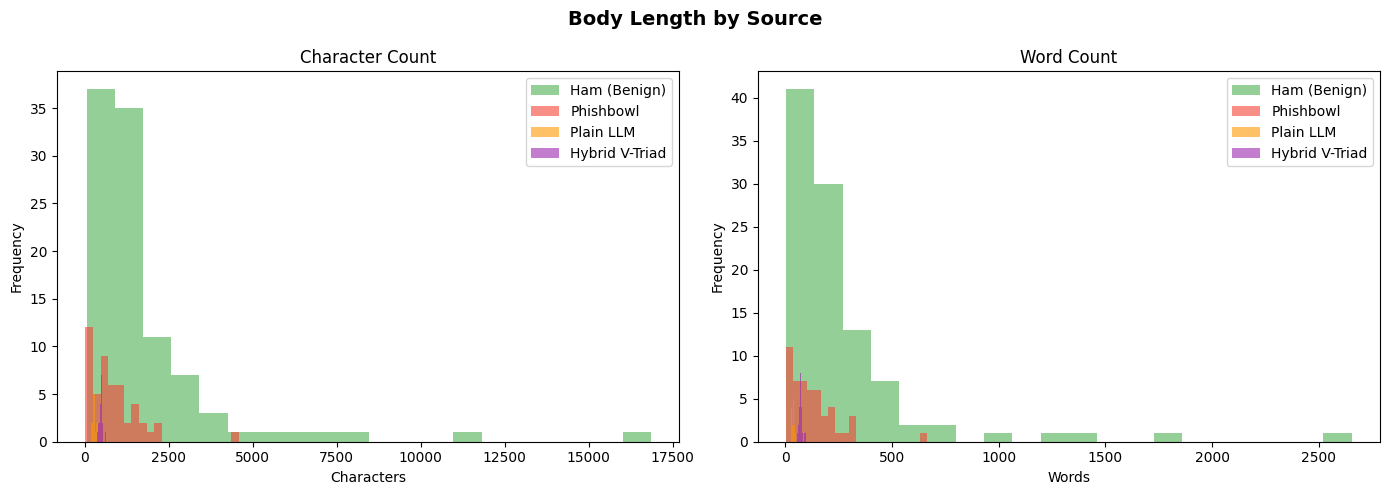

C:\Users\datta\AppData\Local\Temp\ipykernel_17268\62330943.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(char_data, labels=SOURCE_LABELS, patch_artist=True)
C:\Users\datta\AppData\Local\Temp\ipykernel_17268\62330943.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(word_data, labels=SOURCE_LABELS, patch_artist=True)


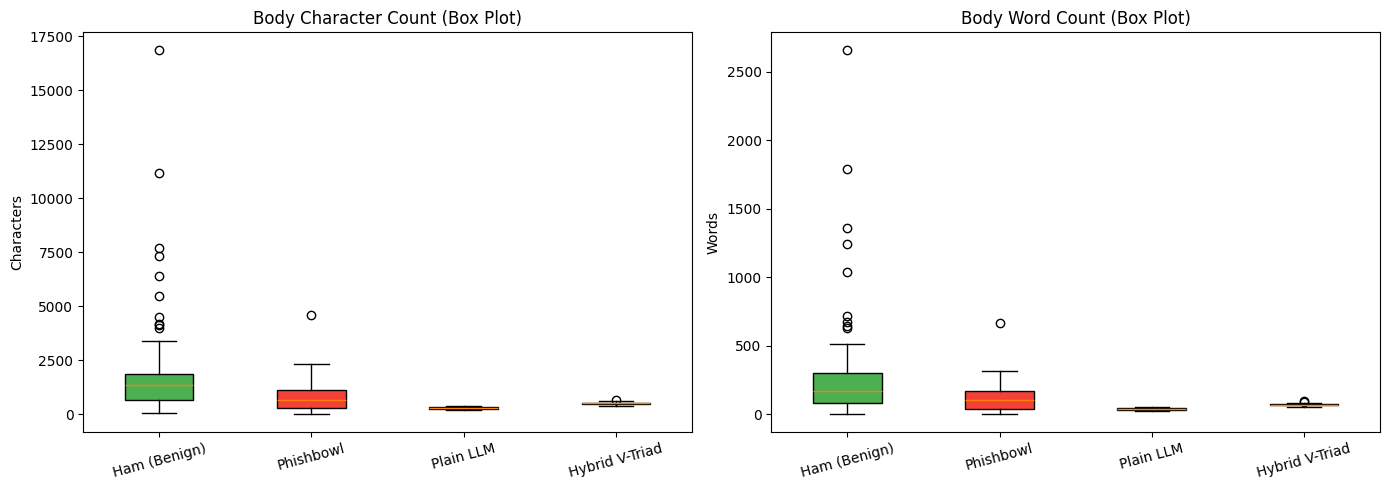

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Body Length by Source', fontsize=14, fontweight='bold')

for src, lbl in zip(SOURCE_ORDER, SOURCE_LABELS):
    sub = df[df['source'] == src]
    axes[0].hist(sub['body_chars'], bins=20, alpha=0.6, label=lbl, color=PALETTE[src])
    axes[1].hist(sub['body_words'], bins=20, alpha=0.6, label=lbl, color=PALETTE[src])

axes[0].set_title('Character Count')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].set_title('Word Count')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

# Box plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
char_data = [df[df['source']==s]['body_chars'].values for s in SOURCE_ORDER]
word_data = [df[df['source']==s]['body_words'].values for s in SOURCE_ORDER]

bp1 = axes[0].boxplot(char_data, labels=SOURCE_LABELS, patch_artist=True)
for patch, src in zip(bp1['boxes'], SOURCE_ORDER):
    patch.set_facecolor(PALETTE[src])
axes[0].set_title('Body Character Count (Box Plot)')
axes[0].set_ylabel('Characters')
axes[0].tick_params(axis='x', rotation=15)

bp2 = axes[1].boxplot(word_data, labels=SOURCE_LABELS, patch_artist=True)
for patch, src in zip(bp2['boxes'], SOURCE_ORDER):
    patch.set_facecolor(PALETTE[src])
axes[1].set_title('Body Word Count (Box Plot)')
axes[1].set_ylabel('Words')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 3. Subject Line Analysis

C:\Users\datta\AppData\Local\Temp\ipykernel_17268\511316127.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(subj_data, labels=SOURCE_LABELS, patch_artist=True)


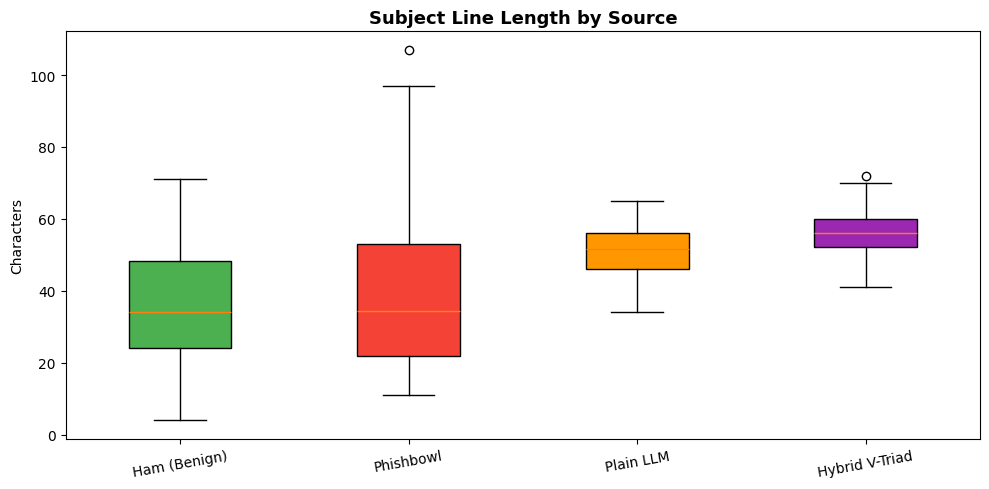


Mean subject length:
  Ham (Benign)        : 36.7 chars
  Phishbowl           : 40.7 chars
  Plain LLM           : 50.6 chars
  Hybrid V-Triad      : 56.1 chars


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
subj_data = [df[df['source']==s]['subject_chars'].values for s in SOURCE_ORDER]
bp = ax.boxplot(subj_data, labels=SOURCE_LABELS, patch_artist=True)
for patch, src in zip(bp['boxes'], SOURCE_ORDER):
    patch.set_facecolor(PALETTE[src])
ax.set_title('Subject Line Length by Source', fontsize=13, fontweight='bold')
ax.set_ylabel('Characters')
ax.tick_params(axis='x', rotation=10)
plt.tight_layout()
plt.show()

print('\nMean subject length:')
for src, lbl in zip(SOURCE_ORDER, SOURCE_LABELS):
    mean = df[df['source']==src]['subject_chars'].mean()
    print(f'  {lbl:<20}: {mean:.1f} chars')

## 4. URL Presence & Count

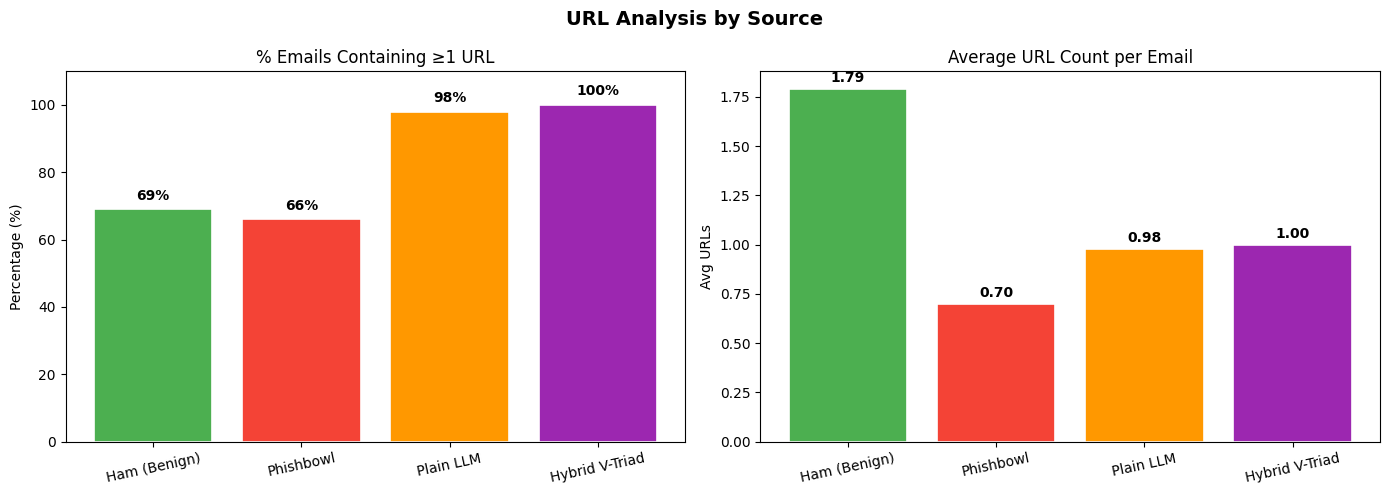


URL stats per source:
  Ham (Benign)        : 69% have URL | avg 1.79 | max 15
  Phishbowl           : 66% have URL | avg 0.70 | max 2
  Plain LLM           : 98% have URL | avg 0.98 | max 1
  Hybrid V-Triad      : 100% have URL | avg 1.00 | max 1


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('URL Analysis by Source', fontsize=14, fontweight='bold')

# Left: % emails with at least one URL
url_pct = df.groupby('source')['has_url'].mean() * 100
url_pct = url_pct.reindex(SOURCE_ORDER)
bars = axes[0].bar(SOURCE_LABELS, url_pct.values,
                   color=[PALETTE[s] for s in SOURCE_ORDER], edgecolor='white', linewidth=1.2)
axes[0].set_title('% Emails Containing ≥1 URL')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_ylim(0, 110)
axes[0].tick_params(axis='x', rotation=12)
for bar, val in zip(bars, url_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{val:.0f}%', ha='center', va='bottom', fontweight='bold')

# Right: avg URL count per email
avg_urls = df.groupby('source')['n_urls'].mean().reindex(SOURCE_ORDER)
bars2 = axes[1].bar(SOURCE_LABELS, avg_urls.values,
                    color=[PALETTE[s] for s in SOURCE_ORDER], edgecolor='white', linewidth=1.2)
axes[1].set_title('Average URL Count per Email')
axes[1].set_ylabel('Avg URLs')
axes[1].tick_params(axis='x', rotation=12)
for bar, val in zip(bars2, avg_urls.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nURL stats per source:')
for src, lbl in zip(SOURCE_ORDER, SOURCE_LABELS):
    sub = df[df['source']==src]
    pct = sub['has_url'].mean()*100
    avg = sub['n_urls'].mean()
    mx  = sub['n_urls'].max()
    print(f'  {lbl:<20}: {pct:.0f}% have URL | avg {avg:.2f} | max {int(mx)}')

## 5. Cue Count Distribution

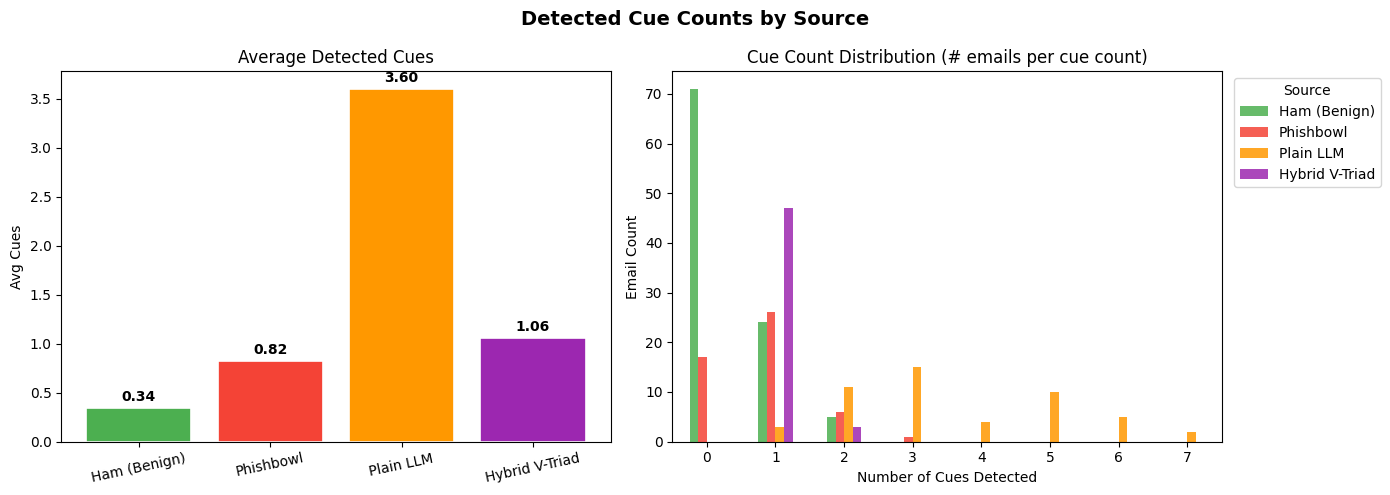


Cue type breakdown by source:
  Ham (Benign): [('suspicious_link', 11), ('spelling_grammar', 10), ('too_good_true', 4), ('urgency', 4), ('suspicious_sender', 2), ('emotional_appeal', 2), ('generic_greeting', 1)]
  Phishbowl: [('suspicious_link', 33), ('urgency', 6), ('emotional_appeal', 1), ('generic_greeting', 1)]
  Plain LLM: [('urgency', 42), ('generic_greeting', 34), ('spelling_grammar', 23), ('suspicious_link', 22), ('suspicious_sender', 20), ('personal_info', 18), ('threats', 11), ('emotional_appeal', 6), ('too_good_true', 4)]
  Hybrid V-Triad: [('suspicious_link', 50), ('emotional_appeal', 2), ('suspicious_sender', 1)]


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Detected Cue Counts by Source', fontsize=14, fontweight='bold')

# Average cue bar chart
avg_cues = df.groupby('source')['n_cues'].mean().reindex(SOURCE_ORDER)
bars = axes[0].bar(SOURCE_LABELS, avg_cues.values,
                   color=[PALETTE[s] for s in SOURCE_ORDER], edgecolor='white', linewidth=1.2)
axes[0].set_title('Average Detected Cues')
axes[0].set_ylabel('Avg Cues')
axes[0].tick_params(axis='x', rotation=12)
for bar, val in zip(bars, avg_cues.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
                 f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

# Distribution across cue counts
cue_dist = df.groupby(['source', 'n_cues']).size().unstack(fill_value=0)
cue_dist = cue_dist.reindex(SOURCE_ORDER)
cue_dist.index = SOURCE_LABELS
cue_dist.T.plot(kind='bar', ax=axes[1],
                color=[PALETTE[s] for s in SOURCE_ORDER], alpha=0.85)
axes[1].set_title('Cue Count Distribution (# emails per cue count)')
axes[1].set_xlabel('Number of Cues Detected')
axes[1].set_ylabel('Email Count')
axes[1].legend(title='Source', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print('\nCue type breakdown by source:')
for src, lbl in zip(SOURCE_ORDER, SOURCE_LABELS):
    all_cues = [c for clist in df[df['source']==src]['cues'] for c in clist]
    freq = Counter(all_cues).most_common()
    print(f'  {lbl}:', freq if freq else '(no cues detected)')

## 6. Urgency Word Density

C:\Users\datta\AppData\Local\Temp\ipykernel_17268\133941749.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(urgency_data, labels=SOURCE_LABELS, patch_artist=True)


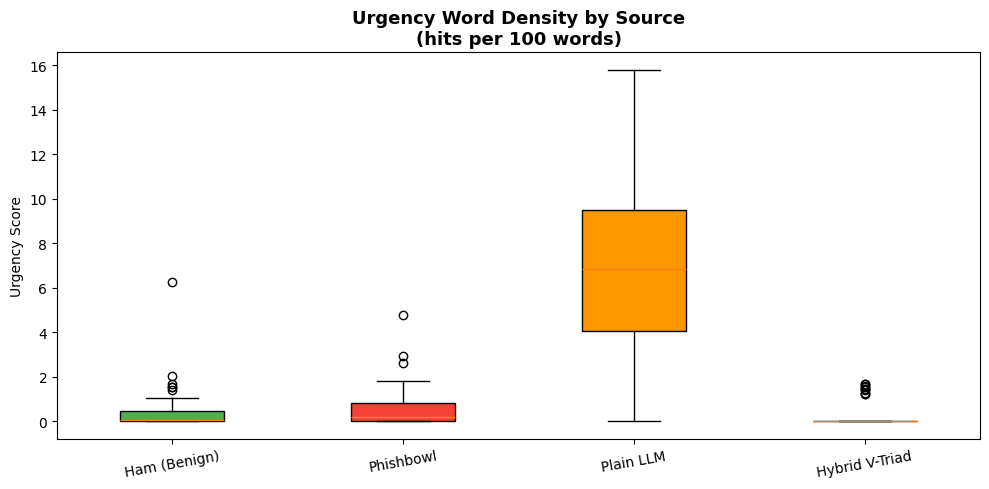


Mean urgency density:
  Ham (Benign)        : 0.3397 urgency hits per 100 words
  Phishbowl           : 0.5993 urgency hits per 100 words
  Plain LLM           : 6.7906 urgency hits per 100 words
  Hybrid V-Triad      : 0.2881 urgency hits per 100 words


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
urgency_data = [df[df['source']==s]['urgency_score'].values for s in SOURCE_ORDER]
bp = ax.boxplot(urgency_data, labels=SOURCE_LABELS, patch_artist=True)
for patch, src in zip(bp['boxes'], SOURCE_ORDER):
    patch.set_facecolor(PALETTE[src])
ax.set_title('Urgency Word Density by Source\n(hits per 100 words)', fontsize=13, fontweight='bold')
ax.set_ylabel('Urgency Score')
ax.tick_params(axis='x', rotation=10)
plt.tight_layout()
plt.show()

print('\nMean urgency density:')
for src, lbl in zip(SOURCE_ORDER, SOURCE_LABELS):
    mean = df[df['source']==src]['urgency_score'].mean()
    print(f'  {lbl:<20}: {mean:.4f} urgency hits per 100 words')

## 7. Lexical Diversity

C:\Users\datta\AppData\Local\Temp\ipykernel_17268\2681376862.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(lex_data, labels=SOURCE_LABELS, patch_artist=True)


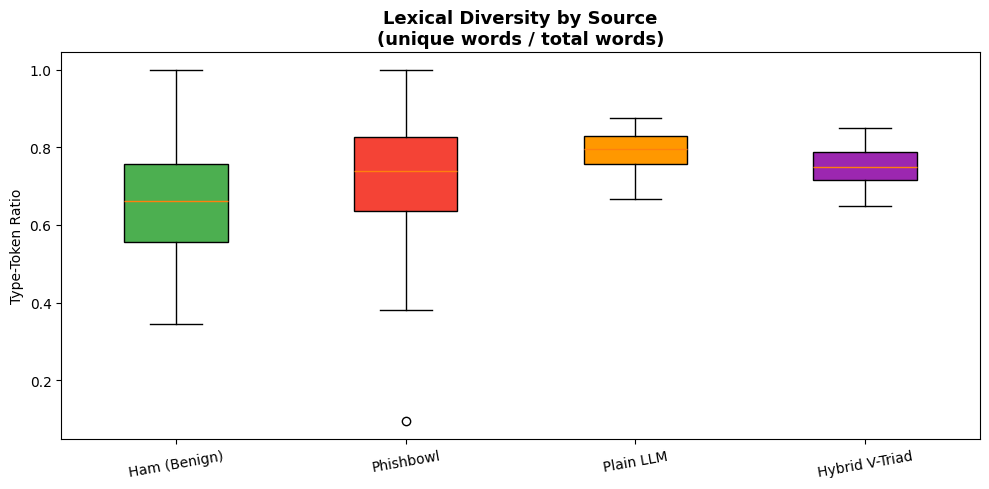


Mean lexical diversity (1.0 = all unique words, lower = more repetitive):
  Ham (Benign)        : 0.6676
  Phishbowl           : 0.7294
  Plain LLM           : 0.7896
  Hybrid V-Triad      : 0.7516


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
lex_data = [df[df['source']==s]['lex_diversity'].values for s in SOURCE_ORDER]
bp = ax.boxplot(lex_data, labels=SOURCE_LABELS, patch_artist=True)
for patch, src in zip(bp['boxes'], SOURCE_ORDER):
    patch.set_facecolor(PALETTE[src])
ax.set_title('Lexical Diversity by Source\n(unique words / total words)', fontsize=13, fontweight='bold')
ax.set_ylabel('Type-Token Ratio')
ax.tick_params(axis='x', rotation=10)
plt.tight_layout()
plt.show()

print('\nMean lexical diversity (1.0 = all unique words, lower = more repetitive):')
for src, lbl in zip(SOURCE_ORDER, SOURCE_LABELS):
    mean = df[df['source']==src]['lex_diversity'].mean()
    print(f'  {lbl:<20}: {mean:.4f}')

## 8. Sender Domain Analysis

In [11]:
def extract_tld(sender):
    match = re.search(r'@([\w.\-]+)', str(sender))
    if not match: return 'unknown'
    domain = match.group(1)
    parts = domain.split('.')
    return parts[-1] if len(parts) > 1 else domain

def extract_domain(sender):
    match = re.search(r'@([\w.\-]+)', str(sender))
    return match.group(1).lower() if match else 'unknown'

df['sender_tld']    = df['sender'].apply(extract_tld)
df['sender_domain'] = df['sender'].apply(extract_domain)

print('=== SENDER TLD BREAKDOWN BY SOURCE ===')
for src, lbl in zip(SOURCE_ORDER, SOURCE_LABELS):
    sub = df[df['source']==src]
    tld_counts = sub['sender_tld'].value_counts().head(6)
    print(f'\n  {lbl}:')
    for tld, cnt in tld_counts.items():
        print(f'    .{tld:<8} {cnt} emails')

# Flag suspicious TLDs
SUSP_TLDS = {'net', 'org', 'xyz', 'online', 'site', 'top', 'info', 'biz'}
df['suspicious_tld'] = df['sender_tld'].isin(SUSP_TLDS)
print('\n=== % EMAILS WITH NON-.COM/.EDU SENDER TLD ===')
for src, lbl in zip(SOURCE_ORDER, SOURCE_LABELS):
    sub = df[df['source']==src]
    pct = sub['suspicious_tld'].mean()*100
    print(f'  {lbl:<20}: {pct:.0f}%')

=== SENDER TLD BREAKDOWN BY SOURCE ===

  Ham (Benign):
    .com      58 emails
    .net      11 emails
    .org      11 emails
    .edu      9 emails
    .ie       2 emails
    .au       2 emails

  Phishbowl:
    .unknown  30 emails
    .com      10 emails
    .edu      3 emails
    .org      2 emails
    .uk       2 emails
    .net      1 emails

  Plain LLM:
    .net      29 emails
    .com      20 emails
    .org      1 emails

  Hybrid V-Triad:
    .com      50 emails

=== % EMAILS WITH NON-.COM/.EDU SENDER TLD ===
  Ham (Benign)        : 22%
  Phishbowl           : 6%
  Plain LLM           : 60%
  Hybrid V-Triad      : 0%


## 9. Overall Comparison — Radar / Heatmap

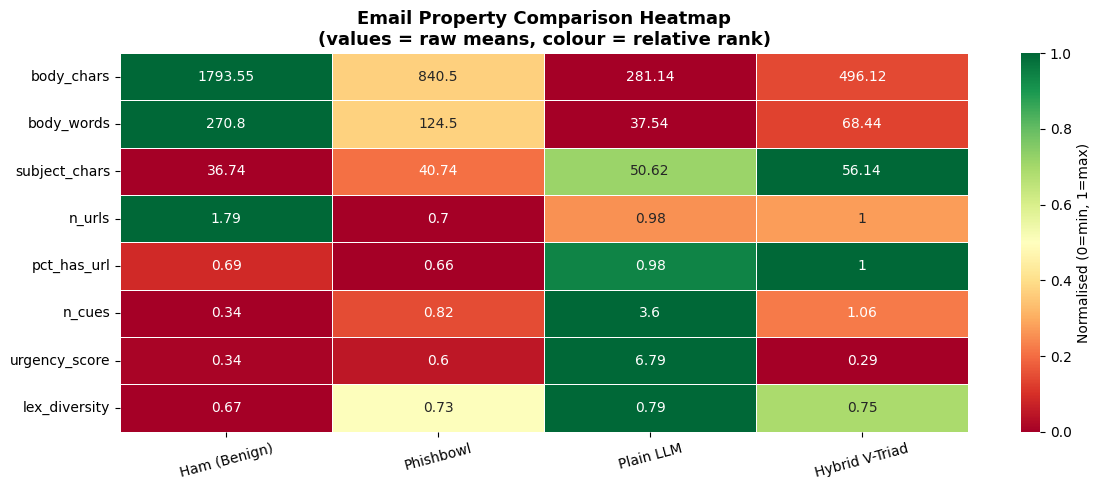

In [12]:
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# Normalise all metrics 0–1 across sources for heatmap
agg = df.groupby('source').agg(
    body_chars    = ('body_chars',    'mean'),
    body_words    = ('body_words',    'mean'),
    subject_chars = ('subject_chars', 'mean'),
    n_urls        = ('n_urls',        'mean'),
    pct_has_url   = ('has_url',       'mean'),
    n_cues        = ('n_cues',        'mean'),
    urgency_score = ('urgency_score', 'mean'),
    lex_diversity = ('lex_diversity', 'mean'),
).reindex(SOURCE_ORDER)

agg.index = SOURCE_LABELS

# Normalise columns
norm_agg = (agg - agg.min()) / (agg.max() - agg.min() + 1e-9)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    norm_agg.T, annot=agg.T.round(2), fmt='g',
    cmap='RdYlGn', linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'Normalised (0=min, 1=max)'}
)
ax.set_title('Email Property Comparison Heatmap\n(values = raw means, colour = relative rank)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('')
plt.xticks(rotation=15)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Final Summary Table

In [13]:
print('\n' + '='*90)
print('FINAL COMPARISON SUMMARY')
print('='*90)
print(f'{"Metric":<28} {"Ham":>12} {"Phishbowl":>14} {"Plain LLM":>12} {"V-Triad":>12}')
print('-'*90)

rows = [
    ('Avg body chars',     'body_chars',    '{:.0f}'),
    ('Avg body words',     'body_words',    '{:.0f}'),
    ('Avg subject chars',  'subject_chars', '{:.0f}'),
    ('Avg URLs per email', 'n_urls',        '{:.2f}'),
    ('% with URL',         'pct_has_url',   '{:.0%}'),
    ('Avg cues detected',  'n_cues',        '{:.2f}'),
    ('Urgency density',    'urgency_score', '{:.3f}'),
    ('Lexical diversity',  'lex_diversity', '{:.3f}'),
]

for label, col, fmt in rows:
    vals = [agg.loc[lbl, col] for lbl in SOURCE_LABELS]
    formatted = [fmt.format(v) for v in vals]
    print(f'{label:<28} {formatted[0]:>12} {formatted[1]:>14} {formatted[2]:>12} {formatted[3]:>12}')

print('='*90)


FINAL COMPARISON SUMMARY
Metric                                Ham      Phishbowl    Plain LLM      V-Triad
------------------------------------------------------------------------------------------
Avg body chars                       1794            840          281          496
Avg body words                        271            124           38           68
Avg subject chars                      37             41           51           56
Avg URLs per email                   1.79           0.70         0.98         1.00
% with URL                            69%            66%          98%         100%
Avg cues detected                    0.34           0.82         3.60         1.06
Urgency density                     0.340          0.599        6.791        0.288
Lexical diversity                   0.668          0.729        0.790        0.752
